<h1><b>Predviđanje Cene Bitcoina putem LSTM Modela</b></h1>

Cilj projekta je predikcija kretanja cene Bitcoina korišćenjem metoda mašinskog učenja i neuronskih mreža. Zadatak je da se na osnovu prethodnih vrednosti predvidi buduća cena.

<h2>Izbor i prikupljanje podataka</h2>

Za potrebe projekta korišćeni su istorijski podaci o ceni Bitcoina preuzeti sa Binance platforme putem njihovog API-ja. Izabran je trading par BTC/USDT zato što predstavlja jedan od najlikvidnijih i najtrgovanijih parova, što znači da su podaci stabilni i bez većih prekida. Podaci su prikupljeni u vremenskom intervalu od jednog sata, jer manji intervali uvode previše šuma u podatke, dok veći intervali gube značajan deo informacija o kratkoročnim promenama cene.

<h2>Opis prikupljanja podataka</h2>

Podaci su preuzimani korišćenjem Binance API-ja za OHLCV podatke, koji uključuju vrednosti Open, High, Low, Close i Volume. Zbog ograničenja API-ja, gde je moguće dobiti maksimalno 1000 zapisa po zahtevu, podaci su preuzimani u više iteracija, tako što se svaki naredni zahtev nadovezuje na prethodni vremenski opseg. Nakon preuzimanja, timestamp vrednosti su konvertovane u datetime format, a podaci su organizovani u pandas DataFrame i zadržane su samo relevantne kolone potrebne za dalju analizu.

<h3>Zašto nije korišćen yfinace API</h3>

Iako je u početnoj specifikaciji predloženo korišćenje Yahoo Finance API-ja, u ovom radu je umesto toga korišćen Binance API, pošto Binance omogućava jednostavniji pristup dužim vremenskim serijama i podržava kraće vremenske intervale, kao što je jedan sat, bez dodatnih ograničenja. Ovo je bilo važno jer model zahteva veću količinu podataka kako bi mogao da nauči obrasce u vremenskoj seriji.

<h2>Razlog izbora ovog dataset-a</h2>

Izabrani dataset je pogodan za ovaj zadatak jer predstavlja realne finansijske podatke i ima strukturu vremenske serije, i to omogućava primenu modela kao što je LSTM. Takođe, količina dostupnih podataka je dovoljna za treniranje modela, a kontinuiranost serije omogućava stabilniju analizu. Dodatno, Bitcoin je poznat po svojoj volatilnosti, što ovaj problem čini izazovnijim i zanimljivijim za istraživanje.

In [1]:
"""
import pandas as pd
import requests
import datetime
import time

def get_binance_klines(symbol="BTCUSDT", interval="1h", start="2017-01-01"):# skida istorijske Bitcoin cene sa Binance API.
    ---------------------------------------------
    #Download historical OHLCV data from Binance.
    #interval examples: 1m, 5m, 15m, 1h, 4h, 1d
    ---------------------------------------------
    
    url = "https://api.binance.com/api/v3/klines"# endpoint za price data.
    start_ts = int(pd.Timestamp(start).timestamp() * 1000)# pretvara datum u timestamp.
    end_ts = int(time.time() * 1000)

    all_data = []

    while start_ts < end_ts:# Skida podatke u batch-evima jer API ima limit.
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": start_ts,
            "limit": 1000  # Binance max per request
        }

        data = requests.get(url, params=params).json()

        # Stop if Binance returns empty list (end of available data)
        if not data:
            break

        all_data.extend(data)

        # Move start to last returned timestamp + 1ms
        last_time = data[-1][0]
        start_ts = last_time + 1

        # avoid hitting rate limit
        time.sleep(0.4)

    # Convert into DataFrame
    df = pd.DataFrame(all_data, columns=[
        "OpenTime", "Open", "High", "Low", "Close", "Volume",
        "CloseTime", "QuoteVolume", "Trades", "TakerBuyBase",
        "TakerBuyQuote", "Ignore"
    ])

    # Clean up
    df["OpenTime"] = pd.to_datetime(df["OpenTime"], unit="ms")
    df = df.set_index("OpenTime")

    df = df[["Open", "High", "Low", "Close", "Volume"]].astype(float)

    # Rename to match yfinance naming style
    df.index.name = "Datetime"

    return df
"""

'\nimport pandas as pd\nimport requests\nimport datetime\nimport time\n\ndef get_binance_klines(symbol="BTCUSDT", interval="1h", start="2017-01-01"):# skida istorijske Bitcoin cene sa Binance API.\n    ---------------------------------------------\n    #Download historical OHLCV data from Binance.\n    #interval examples: 1m, 5m, 15m, 1h, 4h, 1d\n    ---------------------------------------------\n\n    url = "https://api.binance.com/api/v3/klines"# endpoint za price data.\n    start_ts = int(pd.Timestamp(start).timestamp() * 1000)# pretvara datum u timestamp.\n    end_ts = int(time.time() * 1000)\n\n    all_data = []\n\n    while start_ts < end_ts:# Skida podatke u batch-evima jer API ima limit.\n        params = {\n            "symbol": symbol,\n            "interval": interval,\n            "startTime": start_ts,\n            "limit": 1000  # Binance max per request\n        }\n\n        data = requests.get(url, params=params).json()\n\n        # Stop if Binance returns empty list (e

<h2>Učitavanje podataka</h2>

Podaci su nakon preuzimanja sačuvani u CSV fajl i zatim učitani pomoću pandas biblioteke. Prilikom učitavanja, vremenska kolona je postavljena kao indeks i konvertovana u datetime format, kako bi se zadržala struktura vremenske serije. Ovo omogućava jednostavniji rad sa podacima u daljim koracima.

Poslečitavanja, prikazuje se prvih nekoliko redova dataset-a kako bi se videlo kako podaci izgledaju. Vremenska kolona je indeksirana, a prisutne su osnovne vrednosti kao što su Open, High, Low, Close i Volume, koje će se dalje koristiti u modelu.

In [2]:
#df = get_binance_klines("BTCUSDT", interval="1h", start="2017-01-01")# skida Bitcoin cenu po satu od 2017.
#df.head()# prikaz prvih redova
!pip install -q pandas
import pandas as pd
df = pd.read_csv("btc_1h.csv", index_col=0, parse_dates=True)# ucitavanje podataka
df.head()

,Open,High,Low,Close,Volume
Datetime,,,,,
2017-08-17 04:00:00,4261.48,4313.62,4261.32,4308.83,47.181009
2017-08-17 05:00:00,4308.83,4328.69,4291.37,4315.32,23.234916
2017-08-17 06:00:00,4330.29,4345.45,4309.37,4324.35,7.229691
2017-08-17 07:00:00,4316.62,4349.99,4287.41,4349.99,4.443249
2017-08-17 08:00:00,4333.32,4377.85,4333.32,4360.69,0.972807


<h2>Kreiranje dodatnih karakteristika</h2>

U cilju poboljšanja performansi modela, nad osnovnim podacima su generisane dodatne karakteristike koje opisuju kretanje cene kroz vreme. Ove karakteristike uključuju različite tipove informacija, kao što su procentualne promene cene, statističke mere, kao i tehnički indikatori koji se često koriste u finansijskoj analizi.

Korišćene su promene cene kroz vreme, kao što su povrat u poslednjem satu i dnevni povrat, kako bi model lakše uočio relativne promene umesto apsolutnih vrednosti. Takođe su izračunate pokretne sredine i standardne devijacije koje daju uvid u trend i volatilnost u određenom vremenskom prozoru.

Dodatno, korišćene su tzv. lag vrednosti, odnosno prethodne cene u određenim vremenskim trenucima, čime se modelu omogućava da uči iz istorijskih obrazaca. Pored toga, uključeni su i tehnički indikatori kao što su RSI, MACD, Bollinger Bands, kao i SMA i EMA, koji predstavljaju standardne alate u analizi tržišta.

Na kraju, definisane su ciljne promenljive koje predstavljaju buduću cenu nakon određenog vremenskog perioda (24h, 48h i 7 dana), čime se formuliše zadatak predikcije.

Ispod je ispisana nova tabela

In [3]:
!pip install -q ta
import ta

#return
df["return_1h"] = df["Close"].pct_change()# koliko se cena promenila u % zato što model lakše uči promene nego apsolutne cene.
df['daily_return'] = df['Close'].pct_change(24)# Dnevni prinos
#mean/std
df["rolling_mean_24h"] = df["Close"].rolling(24).mean()# prosečna cena zadnja 24h
df["rolling_std_24h"] = df["Close"].rolling(24).std()# volatilnost
#lag
df["close_lag_6h"] = df["Close"].shift(6)# cena pre 6h
df["close_lag_12h"] = df["Close"].shift(12)# cena pre 12h
df["close_lag_24h"] = df["Close"].shift(24)# cena pre 24h
df['close_lag_48h'] = df['Close'].shift(48)  # Cena pre 48h
df['close_lag_168h'] = df['Close'].shift(168)  # Cena pre 7 dana

# RSI
df['RSI_14'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()

# MACD
macd = ta.trend.MACD(df['Close'], window_slow=26, window_fast=12, window_sign=9)
df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()  # MACD signal linija
df['MACD_hist'] = macd.macd_diff()  # MACD histogram

# Bollinger Bands
bb = ta.volatility.BollingerBands(df['Close'], window=20, window_dev=2)
df['BB_mavg'] = bb.bollinger_mavg()  # Srednja Bollinger linija
df['BB_upper'] = bb.bollinger_hband()  # Gornja Bollinger linija
df['BB_lower'] = bb.bollinger_lband()  # Donja Bollinger linija

# SMA i EMA
df['SMA_20'] = ta.trend.SMAIndicator(df['Close'], window=20).sma_indicator()
df['EMA_20'] = ta.trend.EMAIndicator(df['Close'], window=20).ema_indicator()

# ATR (Average True Range)
df['ATR_14'] = ta.volatility.AverageTrueRange(high=df['High'], low=df['Low'], close=df['Close'], window=14).average_true_range()

# ROC (Rate of Change) - Procenat promene cene u poslednjem periodu
df['ROC'] = ta.momentum.ROCIndicator(df['Close'], window=12).roc()

df["volatility_24h"] = df["return_1h"].rolling(24).std()

# za regresiju
df["price_24h"] = df["Close"].shift(-24)
df["price_48h"] = df["Close"].shift(-48)
df["price_7d"] = df["Close"].shift(-168)

df = df.dropna()# brisanje jer rolling i lag nekada stvaraju prazne vrednosti.
df.head() #ispis :)

,Open,High,Low,Close,Volume,return_1h,daily_return,rolling_mean_24h,rolling_std_24h,close_lag_6h,...,BB_upper,BB_lower,SMA_20,EMA_20,ATR_14,ROC,volatility_24h,price_24h,price_48h,price_7d
Datetime,,,,,,,,,,,,,,,,,,,,,
2017-08-24 04:00:00,4113.58,4148.19,4090.39,4113.98,32.247571,0.000097,0.007440,4145.985833,52.439849,4114.20,...,4249.760962,4067.399038,4158.5800,4123.466923,73.916662,-2.281456,0.006937,4310.20,4297.94,4591.56
2017-08-24 05:00:00,4113.98,4177.64,4113.49,4132.09,28.158769,0.004402,0.019469,4149.273750,48.709115,4114.01,...,4244.510883,4065.546117,4155.0285,4124.288168,73.219043,-0.820398,0.006779,4281.04,4295.75,4598.54
2017-08-24 06:00:00,4132.09,4177.18,4131.91,4133.42,29.921536,0.000322,0.013093,4151.499583,46.579934,4131.00,...,4233.637800,4066.959200,4150.2985,4125.157866,71.222683,-0.240143,0.006666,4302.72,4319.70,4572.99
2017-08-24 07:00:00,4153.97,4173.99,4133.41,4153.32,32.851584,0.004814,0.019250,4154.767917,43.628501,4140.91,...,4219.123982,4073.006018,4146.0650,4127.839974,69.033920,0.880481,0.006709,4329.00,4319.70,4592.16
2017-08-24 08:00:00,4153.80,4206.88,4153.32,4200.00,32.275428,0.011239,0.018429,4157.934583,44.054251,4131.92,...,4215.620914,4074.941086,4145.2810,4134.712358,67.928640,1.981352,0.006652,4332.17,4319.70,4586.51


<h2><b>1) TEMPORAL SPLIT</b></h2>

Podaci su podeljeni na trening, validacioni i test skup tako da se zadrži vremenski redosled. Nije korišćen random split, jer bi to dovelo do mešanja prošlih i budućih vrednosti, što nije ispravno za vremenske serije.

Korišćen je odnos 60% za trening, 20% za validaciju i 20% za test. Najstariji podaci su korišćeni za treniranje, dok su noviji podaci ostavljeni za validaciju i testiranje, kako bi se bolje simulirala realna situacija predikcije.

In [4]:
# -----------------------------
# 1) TEMPORAL SPLIT
# -----------------------------

# izdvajamo target
target_col = "price_24h"# za sad 24h, 48h i 7d kasnije treba za test najboljeg mozela ili bar kada uspe 24h da dobije dobar rezultat prvo


features = ["Close", "Volume", "High", "Low"]

# indeks za split (60/20/20)
n = len(df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

#najstariji podaci idu za train, onda za vel i na kraju test
train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

#print(len(train_df), len(val_df), len(test_df))# plot za bolji pregled i da izgleda profesionalnije

<h2>Vizuelizacija podele podataka</h2>

Na grafiku je prikazana podela dataset-a na trening, validacioni i test skup. Može se videti da je većina podataka korišćena za treniranje modela, dok su manji delovi ostavljeni za validaciju i testiranje, u skladu sa prethodno definisanim odnosom.

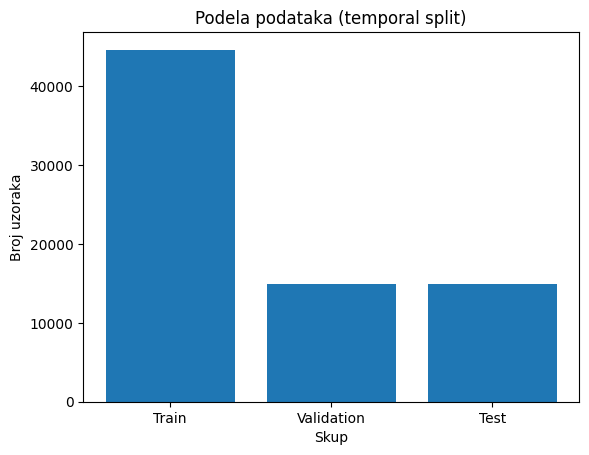

In [5]:
import matplotlib.pyplot as plt

splits = ["Train", "Validation", "Test"]
sizes = [len(train_df), len(val_df), len(test_df)]

plt.figure()
plt.bar(splits, sizes)
plt.title("Podela podataka (temporal split)")
plt.xlabel("Skup")
plt.ylabel("Broj uzoraka")
plt.show()

<h2>2) SCALING</h2>

Pre treniranja modela urađena je normalizacija podataka pomoću StandardScaler metode. Ova transformacija skaluje podatke tako da imaju srednju vrednost 0 i standardnu devijaciju 1, što pomaže modelu da lakše uči.

Scaler je fitovan samo na trening podacima, dok su validacioni i test skup samo transformisani. Ovo je važno kako bi se izbeglo korišćenje informacija iz budućnosti prilikom treniranja modela.

In [6]:
# -----------------------------
# 2) SCALING
# -----------------------------

!pip install -q scikit-learn
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# FIT samo na train
train_df[features] = scaler.fit_transform(train_df[features])

# TRANSFORM na val i test
val_df[features] = scaler.transform(val_df[features])
test_df[features] = scaler.transform(test_df[features])

<h2>3) SEQUENCE CREATION</h2>

Pošto LSTM model ne radi sa pojedinačnim vrednostima već sa nizovima, podaci su pretvoreni u sekvence pomoću sliding window pristupa. To znači da model kao ulaz dobija poslednjih 24 vrednosti, a zatim pokušava da predvidi narednu vrednost.

Na ovaj način model ne gleda samo trenutnu cenu, već i kontekst iz prethodnog perioda, što je važno kod vremenskih serija. Sekvence su napravljene posebno za trening, validaciju i test skup.

<h3>Dimenzije podataka</h3>

Nakon formiranja sekvenci, podaci su dobili trodimenzionalni oblik. Prva dimenzija predstavlja broj uzoraka, druga dužinu sekvence (window size), dok treća predstavlja broj ulaznih karakteristika. Ovakav format je neophodan za rad sa LSTM modelima koji očekuju sekvencijalne ulaze.

In [16]:
# -----------------------------
# 3) SEQUENCE CREATION
# -----------------------------

import numpy as np

def create_sequences(data, target, window=168):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(target[i+window])
    return np.array(X), np.array(y)

window_size = 24

X_train, y_train = create_sequences(
    train_df[features].values,
    train_df[target_col].values,
    window_size
)

X_val, y_val = create_sequences(
    val_df[features].values,
    val_df[target_col].values,
    window_size
)

X_test, y_test = create_sequences(
    test_df[features].values,
    test_df[target_col].values,
    window_size
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (44607, 24, 4)
Validation shape: (14853, 24, 4)
Test shape: (14854, 24, 4)


<h2>4) TARGET SCALING</h2>

Target vrednosti su takođe normalizovane pomoću StandardScaler metode. Ovo je urađeno zato što su vrednosti cene velike, pa normalizacija pomaže modelu da stabilnije uči.

Scaler je fitovan samo na trening podacima, a zatim primenjen na validacioni i test skup, kako bi se izbeglo korišćenje informacija iz budućnosti.

In [8]:
# -----------------------------
# 4) TARGET SCALING
# -----------------------------

from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()

# FIT samo na train target
y_train = y_scaler.fit_transform(y_train.reshape(-1, 1))

# TRANSFORM val i test
y_val = y_scaler.transform(y_val.reshape(-1, 1))
y_test = y_scaler.transform(y_test.reshape(-1, 1))

<h2>5) TORCH DATASET</h2>

Podaci su prilagođeni za rad u PyTorch-u tako što je definisana Dataset klasa koja vraća ulazne sekvence i target vrednosti. Sve vrednosti su konvertovane u tensor format.

Zatim su napravljeni DataLoader objekti koji omogućavaju učitavanje podataka u manjim batch-evima tokom treniranja. Shuffle opcija je isključena kako bi se zadržao vremenski redosled podataka.

In [ ]:
# -----------------------------
# 5) TORCH DATASET
# -----------------------------
!pip install -q torch torchvision torchaudio

import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset   = TimeSeriesDataset(X_val, y_val)
test_dataset  = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)#shuffle mora da bude false zato sto su podaci vremenski poredjani
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

<h2>LSTM model za predikciju cene</h2>

Za modelovanje vremenske serije korišćen je LSTM (Long Short-Term Memory) model, koji je pogodan za rad sa sekvencijalnim podacima jer može da uči zavisnosti između prethodnih i budućih vrednosti. LSTM je posebno koristan kod finansijskih podataka, gde postoje vremenske zavisnosti i obrasci koji se razvijaju kroz vreme.

Model kao ulaz prima sekvence prethodnih vrednosti, a kao izlaz daje predikciju buduće cene. U implementaciji se koristi poslednji izlaz iz sekvence, koji predstavlja agregiranu informaciju o prethodnim vrednostima, i prosleđuje se kroz potpuno povezani sloj kako bi se dobila konačna predikcija.

<h3>Izbor arhitekture modela</h3>

U početnoj verziji korišćen je složeniji model sa više LSTM slojeva. Međutim, tokom eksperimentisanja primećeno je da takav model ne daje bolje rezultate, već dovodi do lošije generalizacije i nestabilnijeg treniranja.

Zbog toga je model pojednostavljen na jedan LSTM sloj sa manjim brojem neurona i dodatim dropout slojem radi regularizacije. Ovakva arhitektura se pokazala stabilnijom i dala je bolje rezultate na validacionom skupu.

<h3>Poređenje modela</h3>

Na grafu ispod prikazano je poređenje performansi različitih modela. Može se primetiti da jednostavniji LSTM model daje bolje rezultate od složenijeg, ali i dalje ne nadmašuje baseline pristup.

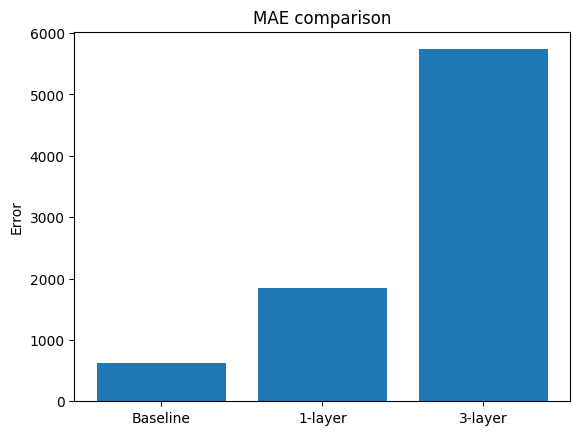

In [10]:
results_1layer = {
    "MAE": 1848.63,
    "RMSE": 3417.88,
    "R2": 0.9567
}

results_3layer = {
    "MAE": 5734.38,
    "RMSE": 9682.65,
    "R2": 0.6523
}

baseline_results = {
    "MAE": 624.56,
    "RMSE": 1027.11,
    "R2": 0.9961
}

import matplotlib.pyplot as plt

models = ["Baseline", "1-layer", "3-layer"]
mae = [624.56, 1848.63, 5734.38]

plt.bar(models, mae)
plt.title("MAE comparison")
plt.ylabel("Error")
plt.show()

<h3>Analiza rezultata modela</h3>

Dobijeni rezultati pokazuju da jednostavniji LSTM model postiže značajno bolje performanse u odnosu na složeniju verziju sa više slojeva. Složeniji model ima veću grešku i lošiju generalizaciju, što ukazuje na overfitting.

Međutim, poređenjem sa baseline modelom (koji predviđa da će buduća cena biti jednaka trenutnoj), uočava se da ni jedan od treniranih modela ne postiže bolje rezultate. Ovo ukazuje na to da je problem predikcije kratkoročnog kretanja cene izuzetno težak, i da jednostavni modeli teško mogu nadmašiti osnovne heuristike.

<h2>6) PRICE LSTM MODEL</h2>

Za predikciju buduće cene korišćen je LSTM model, koji je pogodan za rad sa vremenskim serijama jer može da uzme u obzir zavisnosti između prethodnih vrednosti. Model kao ulaz prima sekvence podataka, a kao izlaz daje predikciju cene u narednih 24h.

U implementaciji se koristi poslednji izlaz iz sekvence, koji predstavlja informaciju o celokupnom prethodnom kretanju, i prosleđuje se kroz linearni sloj kako bi se dobila konačna vrednost.

<h3>Izmena arhitekture modela</h3>

U početnoj verziji model je imao tri LSTM sloja. Međutim, tokom testiranja primećeno je da složeniji model daje lošije rezultate i veću grešku na validacionom skupu (kao što se vidi gore)

Zbog toga je model pojednostavljen na jedan LSTM sloj sa manjim brojem neurona i manjim dropout-om. Ova verzija se pokazala stabilnijom tokom treniranja i dala je bolje rezultate u odnosu na dublju arhitekturu.

In [11]:
# -----------------------------
# 6) PRICE LSTM MODEL
# -----------------------------

import torch.nn as nn

class PriceBranch(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.lstm = nn.LSTM(input_size, 64, batch_first=True)
        self.dropout = nn.Dropout(0.2)

        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out)
        
        out = out[:, -1, :]# Uzima se samo poslednji izlaz iz sekvence
        out = self.fc(out)

        return out

<h2>7) TRAINING LOOP</h2>

Model je treniran korišćenjem standardnog trening procesa za neuronske mreže. U svakoj epohi model prolazi kroz ceo trening skup podataka, pri čemu se za svaki batch računaju predikcije, greška i ažuriraju težine modela.

Za optimizaciju su testirani različiti optimizatori (Adam, SGD i RMSprop), kako bi se ispitao njihov uticaj na brzinu i stabilnost treniranja. Kao funkcija gubitka korišćen je SmoothL1Loss (Huber loss), koji predstavlja kompromis između MSE i MAE i manje je osetljiv na ekstremne vrednosti.

<h3>Validacija i evaluacija modela</h3>

Nakon svake epohe model se evaluira na validacionom skupu. Tokom evaluacije računaju se standardne metrike za regresiju: MAE, RMSE, MAPE i R².

Posebno je značajan MAE, jer direktno pokazuje prosečnu grešku u predikciji izraženu u dolarima. Pored toga, izračunat je i baseline model, koji kao predikciju koristi poslednju poznatu cenu iz ulazne sekvence. Ovaj pristup služi kao referenca za procenu uspešnosti modela.

<h3>Stabilizacija treniranja</h3>

Kako bi se poboljšala stabilnost treniranja, korišćeno je nekoliko tehnika. Gradient clipping je primenjen kako bi se sprečilo naglo povećanje gradijenata, što može dovesti do nestabilnog učenja.

Takođe, korišćen je learning rate scheduler koji smanjuje brzinu učenja u slučaju da se validaciona greška ne poboljšava, čime se omogućava finije prilagođavanje modela u kasnijim fazama treniranja.

<h3>Early stopping</h3>

Uveden je i mehanizam za rano zaustavljanje treniranja (early stopping). Ukoliko se validaciona greška ne poboljšava tokom određenog broja epoha, treniranje se prekida kako bi se izbegao overfitting.

In [ ]:
# -----------------------------
# 7) TRAINING LOOP
# -----------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

#optimizer = get_optimizer(optimizer_type='adam', lr=0.0001)# da moze da bira

def training_loop(optimizer_type='adam', lr=0.0001, epochs=20):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = PriceBranch(input_size=len(features)).to(device)

    if optimizer_type == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_type == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_type == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unsupported optimizer type: {optimizer_type}")

    # Kreiraj funkciju gubitka sa težinama
    criterion = torch.nn.SmoothL1Loss()# Huber loss

    # learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # -----------------------------
    # |||| Early stopping setup ||||
    # -----------------------------
    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0

    #epochs = 20

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)  # Model pogađa
            loss = criterion(outputs, y_batch)  # Koliko je model pogrešio
            loss.backward()  # Računanje gradijenata
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.8)  # Stabilizacija treninga (gradient clipping)
            optimizer.step()  # Model uči

            train_loss += loss.item()

        train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_preds = []
        val_true = []
        val_loss = 0

        with torch.no_grad():
            baseline_preds = []

            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()


                val_preds.extend(outputs.cpu().numpy())
                val_true.extend(y_batch.cpu().numpy())

                last_close = X_batch[:, -1, 0]  # 0 = indeks za "Close"
                baseline_preds.extend(last_close.cpu().numpy())
        val_loss = val_loss / len(val_loader)

        # Pretvori u numpy array i reshape za scaler
        val_preds_np = np.array(val_preds).reshape(-1, 1)
        val_true_np = np.array(val_true).reshape(-1, 1)

        baseline_preds_np = np.array(baseline_preds).reshape(-1, 1)
        # vrati u originalnu skalu
        baseline_preds_inv = y_scaler.inverse_transform(baseline_preds_np)

        # VRATI NA ORIGINALNU SKALU (u dolarima)
        val_preds_inv = y_scaler.inverse_transform(val_preds_np)
        val_true_inv = y_scaler.inverse_transform(val_true_np)

        # score evaluacija
        mae = mean_absolute_error(val_true_inv, val_preds_inv)
        rmse = np.sqrt(mean_squared_error(val_true_inv, val_preds_inv))
        r2 = r2_score(val_true_inv, val_preds_inv)

        # MAPE
        val_true_np = np.array(val_true)
        val_preds_np = np.array(val_preds)
        mape = np.mean(np.abs((val_true_inv - val_preds_inv) / val_true_inv)) * 100
        print(f"\n\n-------------\n[ Epoch {epoch+1} ]\n-------------\n | Optimizer: {optimizer_type} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"MAE: {mae:.4f} | "
              f"RMSE: {rmse:.4f} | "
              f"MAPE: {mape:.2f}% | "
              f"R²: {r2:.4f}")
        print("Pogoci:")
        print("np.mean(val_preds):", np.mean(val_preds))
        print("np.mean(val_true):", np.mean(val_true))
        print("Target mean:", np.mean(y_train))
        print("Target std:", np.std(y_train))


        val_preds_np = np.array(val_preds).reshape(-1, 1)
        val_true_np = np.array(val_true).reshape(-1, 1)

        val_preds_inv = y_scaler.inverse_transform(val_preds_np)
        val_true_inv = y_scaler.inverse_transform(val_true_np)

        baseline_mae = mean_absolute_error(val_true_inv, baseline_preds_inv)
        baseline_rmse = np.sqrt(mean_squared_error(val_true_inv, baseline_preds_inv))
        baseline_r2 = r2_score(val_true_inv, baseline_preds_inv)

        print("\nBASELINE:")
        print(f"MAE: {baseline_mae:.4f}")
        print(f"RMSE: {baseline_rmse:.4f}")
        print(f"R2: {baseline_r2:.4f}")

        # Check for early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping...")
            break

        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training vs Validation Loss ({optimizer_type})")

    plt.legend()
    plt.show()

    # Prava cena bitcoin-a vs model vs baseline

    plt.figure(figsize=(12, 6))

    plt.plot(val_true_inv, label="True Price", linewidth=2)
    plt.plot(val_preds_inv, label="Predicted Price", alpha=0.7)
    plt.plot(baseline_preds_inv, label="Baseline (Last Close)", linestyle='dashed')

    plt.title(f"Real vs {optimizer_type} vs Baseline")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()

    plt.show()



-------------
[ Epoch 1 ]
-------------
 | Optimizer: adam | Train Loss: 0.0470 | Val Loss: 0.1537 | MAE: 6019.0278 | RMSE: 9723.4632 | MAPE: 12.46% | R²: 0.6494
Pogoci:
np.mean(val_preds): 0.58514583
np.mean(val_true): 0.92006713
Target mean: 0.0
Target std: 1.0

BASELINE:
MAE: 624.5643
RMSE: 1027.1179
R2: 0.9961


-------------
[ Epoch 2 ]
-------------
 | Optimizer: adam | Train Loss: 0.0113 | Val Loss: 0.1182 | MAE: 4901.2744 | RMSE: 8395.4083 | MAPE: 9.72% | R²: 0.7386
Pogoci:
np.mean(val_preds): 0.6487923
np.mean(val_true): 0.92006713
Target mean: 0.0
Target std: 1.0

BASELINE:
MAE: 624.5643
RMSE: 1027.1179
R2: 0.9961


-------------
[ Epoch 3 ]
-------------
 | Optimizer: adam | Train Loss: 0.0093 | Val Loss: 0.0978 | MAE: 4403.8599 | RMSE: 7582.6449 | MAPE: 8.72% | R²: 0.7868
Pogoci:
np.mean(val_preds): 0.67769414
np.mean(val_true): 0.92006713
Target mean: 0.0
Target std: 1.0

BASELINE:
MAE: 624.5643
RMSE: 1027.1179
R2: 0.9961


-------------
[ Epoch 4 ]
-------------
 | Opti

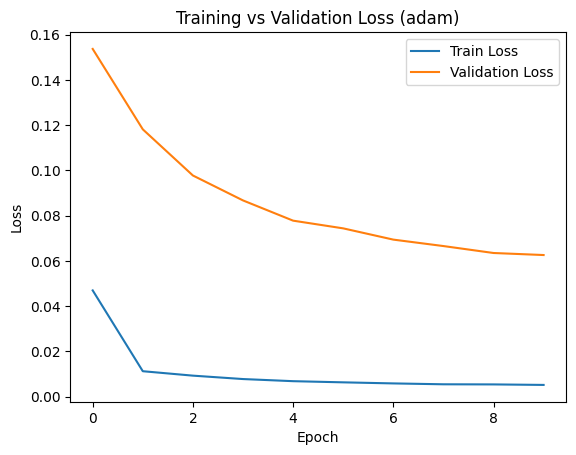

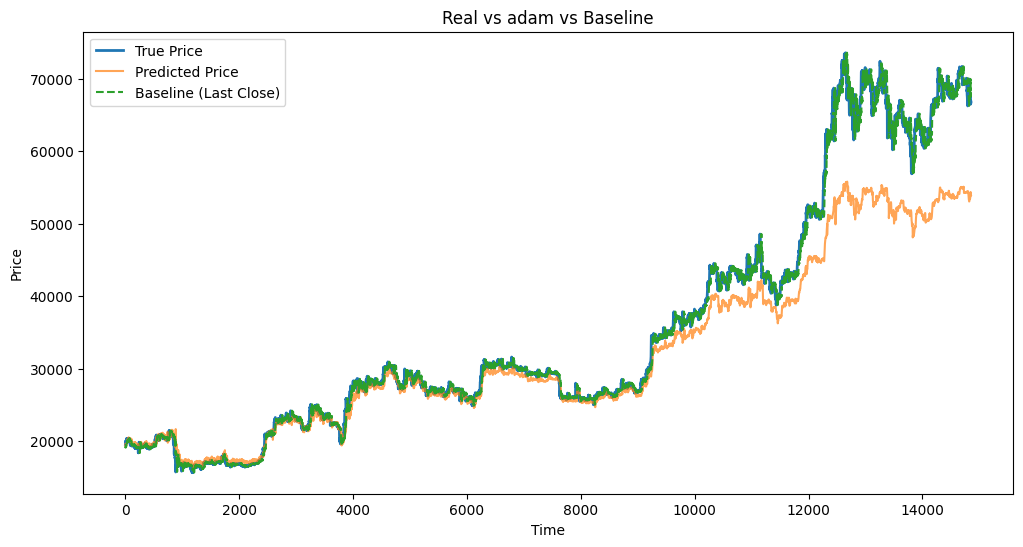

In [13]:
training_loop(optimizer_type='adam', lr=0.0001, epochs=10)

Sa grafa se može uočiti da model uspešno prati opšti trend kretanja cene, ali ne uspeva da prati nagle skokove i padove. Predviđanja su izravnate u odnosu na stvarne vrednosti, pri čemu su ekstremi značajno ublaženi.

Ovakvo ponašanje ukazuje na to da model voli konzistenciju, odnosno voli da igra sigurno sa večim skokovima i padovima da bi minimizovao ukupnu grešku. Kao posledica toga, model ne uspeva da adekvatno uhvati visoku volatilnost karakterističnu za Bitcoin tržište.



-------------
[ Epoch 1 ]
-------------
 | Optimizer: sgd | Train Loss: 0.3170 | Val Loss: 0.4643 | MAE: 13798.6914 | RMSE: 18690.1112 | MAPE: 31.77% | R²: -0.2953
Pogoci:
np.mean(val_preds): 0.14168459
np.mean(val_true): 0.92006713
Target mean: 0.0
Target std: 1.0

BASELINE:
MAE: 624.5643
RMSE: 1027.1179
R2: 0.9961


-------------
[ Epoch 2 ]
-------------
 | Optimizer: sgd | Train Loss: 0.1675 | Val Loss: 0.2372 | MAE: 8941.0303 | RMSE: 12369.1248 | MAPE: 21.02% | R²: 0.4327
Pogoci:
np.mean(val_preds): 0.47216803
np.mean(val_true): 0.92006713
Target mean: 0.0
Target std: 1.0

BASELINE:
MAE: 624.5643
RMSE: 1027.1179
R2: 0.9961


-------------
[ Epoch 3 ]
-------------
 | Optimizer: sgd | Train Loss: 0.0563 | Val Loss: 0.0896 | MAE: 4820.7119 | RMSE: 7241.6214 | MAPE: 12.11% | R²: 0.8055
Pogoci:
np.mean(val_preds): 0.75811535
np.mean(val_true): 0.92006713
Target mean: 0.0
Target std: 1.0

BASELINE:
MAE: 624.5643
RMSE: 1027.1179
R2: 0.9961


-------------
[ Epoch 4 ]
-------------
 | 

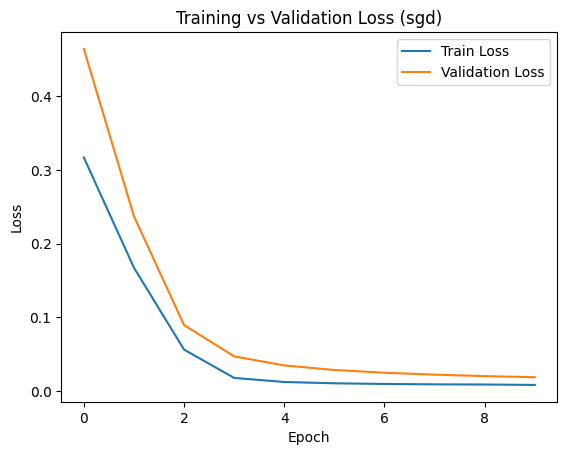

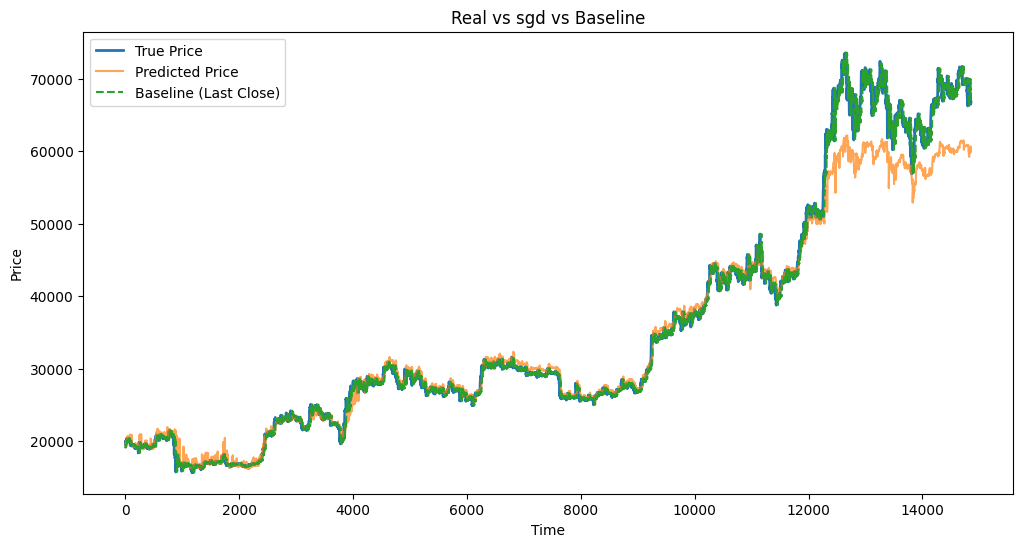

In [14]:
training_loop(optimizer_type='sgd', lr=0.0001, epochs=10)

Uočeno je da model treniran korišćenjem SGD optimizatora nešto bolje prati veće promene u ceni u odnosu na ostale optimizatore. Ipak, ni ovaj model ne uspeva da adekvatno predvidi najveće skokove, kao što je izražen rast cene u aprilu 2025. godine.

Ovo dodatno potvrđuje da modeli imaju ograničenu sposobnost predikcije ekstremnih događaja, koji su karakteristični za visoko volatilna tržišta kao što je tržište kriptovaluta.



-------------
[ Epoch 1 ]
-------------
 | Optimizer: rmsprop | Train Loss: 0.0177 | Val Loss: 0.1524 | MAE: 6120.4517 | RMSE: 9646.4833 | MAPE: 12.71% | R²: 0.6549
Pogoci:
np.mean(val_preds): 0.5735014
np.mean(val_true): 0.92006713
Target mean: 0.0
Target std: 1.0

BASELINE:
MAE: 624.5643
RMSE: 1027.1179
R2: 0.9961


-------------
[ Epoch 2 ]
-------------
 | Optimizer: rmsprop | Train Loss: 0.0053 | Val Loss: 0.0998 | MAE: 4653.2266 | RMSE: 7658.5032 | MAPE: 9.49% | R²: 0.7825
Pogoci:
np.mean(val_preds): 0.6601011
np.mean(val_true): 0.92006713
Target mean: 0.0
Target std: 1.0

BASELINE:
MAE: 624.5643
RMSE: 1027.1179
R2: 0.9961


-------------
[ Epoch 3 ]
-------------
 | Optimizer: rmsprop | Train Loss: 0.0049 | Val Loss: 0.0946 | MAE: 4547.5728 | RMSE: 7448.5373 | MAPE: 9.28% | R²: 0.7943
Pogoci:
np.mean(val_preds): 0.6654519
np.mean(val_true): 0.92006713
Target mean: 0.0
Target std: 1.0

BASELINE:
MAE: 624.5643
RMSE: 1027.1179
R2: 0.9961


-------------
[ Epoch 4 ]
-------------


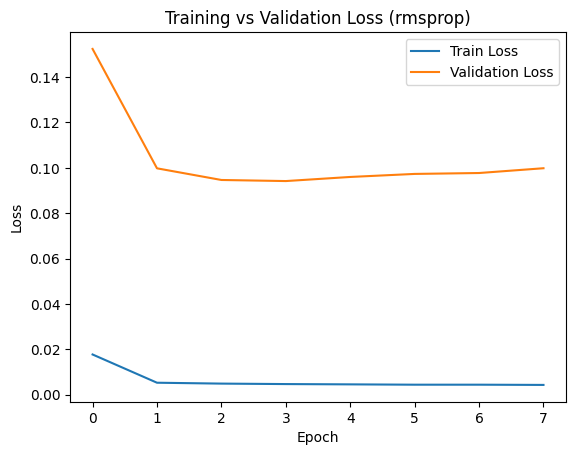

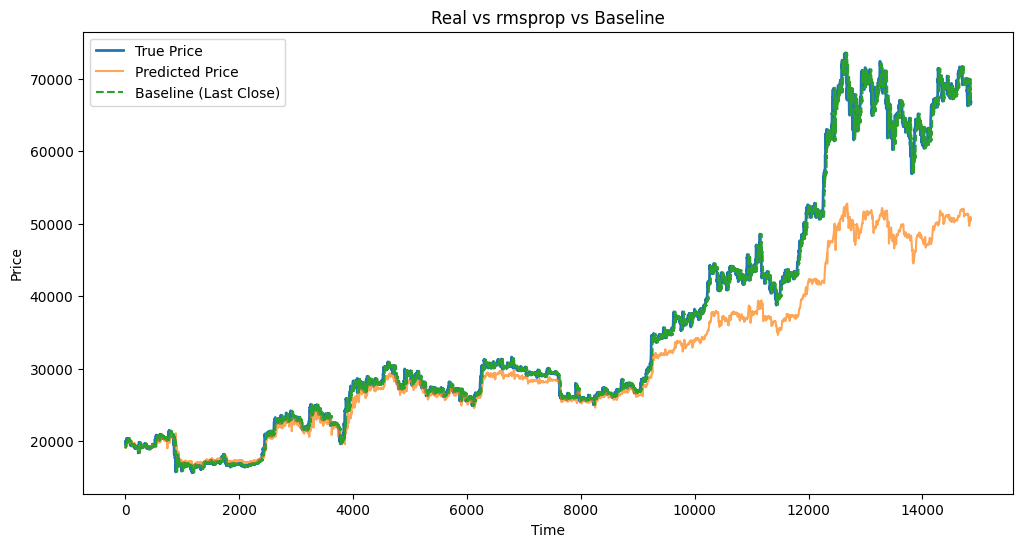

In [15]:
training_loop(optimizer_type='rmsprop', lr=0.0001, epochs=10)

<h3>Uticaj optimizatora</h3>

Testirani su različiti optimizatori (Adam, SGD i RMSprop) kako bi se ispitao njihov uticaj na performanse modela. Rezultati pokazuju da SGD daje najjače rezultate, dok je Adam malo lošiji a RMSprop postiže značajno lošije rezultate.

Ipak, ni jedan od testiranih modela ne uspeva da nadmaši baseline pristup zasnovan na predikciji prethodne vrednosti, koji ostvaruje znatno manju grešku (sa MAE od 600). Ovaj rezultat ukazuje na to da izbor optimizatora nema presudan uticaj na performanse modela u poređenju sa samom prirodom problema.

Naime, visoka autokorelacija vremenske serije Bitcoin cene čini da je predikcija prethodne vrednosti izuzetno jak baseline, koji je teško nadmašiti složenijim modelima bez dodatnih informacija.

Takođe je primećeno da model ima tendenciju da potcenjuje vrednosti, što se može uočiti kroz nižu prosečnu vrednost predikcija u odnosu na stvarne vrednosti. Ovo može ukazivati na pristrasnost modela ili na nedovoljnu sposobnost hvatanja naglih promena u ceni.